In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import ExtraTreesClassifier
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from lightgbm import LGBMClassifier

In [2]:
df = pd.read_csv(r'E:\PROJECTWORSHOP\Eggplant Leaf Disease Detection Dataset\csv_data\hist_basic_all_disease.csv')
df.head()

,0,1,2,3,4,5,6,7,8,9,...,521,522,523,524,525,526,527,528,529,530
0,healthy_leaf,1.118352e-07,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.000004,...,193.635095,231.714395,213.987892,13.915283,15.222168,14.628325,213.112461,54.976789,1.413204e+11,-7.234377e+12
1,healthy_leaf,1.393785e-04,3.050632e-05,0.0,0.0,0.0,0.0,0.0,0.0,0.000449,...,243.581785,247.762500,244.924974,15.607107,15.740473,15.650079,245.423086,33.347309,3.257362e+10,-3.767412e+12
2,healthy_leaf,1.237141e-06,2.061901e-07,0.0,0.0,0.0,0.0,0.0,0.0,0.002450,...,252.653296,253.206044,252.916196,15.895071,15.912449,15.903339,252.925179,14.591401,6.286662e+09,-7.373966e+11
3,healthy_leaf,1.147555e-06,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.000142,...,251.790312,252.528406,252.093962,15.867902,15.891142,15.877467,252.137560,17.791087,8.338340e+09,-9.742823e+11
4,healthy_leaf,4.486156e-04,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.046815,...,252.103648,253.002724,252.887345,15.877772,15.906059,15.902432,252.664572,15.841339,9.673504e+08,-1.244394e+11


In [5]:
X = df.drop(columns=['0'])
y = df['0']
le = LabelEncoder()
y_encoded = le.fit_transform(y)
X.shape[1], y_encoded.shape[0]

(530, 4089)

## RandomForest

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train,y_train)

importances_rf =rf_model.feature_importances_
indices_dt = np.argsort(importances_rf)[::-1]
features_dt = X.columns[indices_dt]

for i in range(len(importances_rf)):
    print(f'feature {features_dt[i]:}: {importances_rf[indices_dt[i]]}')

feature 211: 0.018247076942493282
feature 210: 0.015869175385912284
feature 283: 0.015338307573178177
feature 284: 0.015324301144151424
feature 138: 0.012982966717175795
feature 357: 0.01276031438147953
feature 440: 0.011524800478920925
feature 225: 0.011496443642355405
feature 293: 0.011289819177572024
feature 448: 0.011287901363942898
feature 356: 0.011236660721461645
feature 518: 0.011121672813681286
feature 429: 0.01066877456095498
feature 513: 0.010411450702044758
feature 298: 0.010139154238971817
feature 430: 0.010043696751737824
feature 290: 0.010038074501029077
feature 517: 0.010003376430754947
feature 512: 0.009889814450896683
feature 366: 0.009648035839199163
feature 292: 0.009542325867532623
feature 439: 0.009500167522050063
feature 438: 0.00949524479470444
feature 374: 0.009478564341528108
feature 503: 0.009291921514138322
feature 375: 0.009270395473384917
feature 147: 0.009259117187892869
feature 219: 0.00922687656279664
feature 220: 0.0091854829563767
feature 367: 0.00916

Tổng số feature: 530
Số feature có điểm > 0: 274
Số feature có điểm = 0: 256
Số feature có điểm < 0: 0


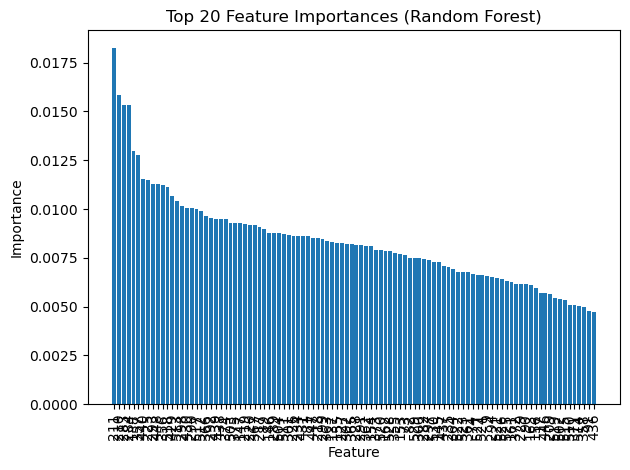

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assume importances_rf and X.columns already correspond to user's data
importances = np.array(importances_rf)
features = np.array(X.columns)

# Create DataFrame
df_imp = pd.DataFrame({
    "feature": features,
    "importance": importances
})

# Count features
num_total = len(df_imp)
num_nonzero = (df_imp["importance"] > 0).sum()
num_zero = (df_imp["importance"] == 0).sum()
num_negative = (df_imp["importance"] < 0).sum()

print(f"Tổng số feature: {num_total}")
print(f"Số feature có điểm > 0: {num_nonzero}")
print(f"Số feature có điểm = 0: {num_zero}")
print(f"Số feature có điểm < 0: {num_negative}")

# Sort and take top 20 for visualization
df_top = df_imp.sort_values("importance", ascending=False).head(100)

# Plot
plt.figure()
plt.bar(df_top["feature"], df_top["importance"])
plt.xticks(rotation=90)
plt.title("Top 20 Feature Importances (Random Forest)")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()


In [13]:
top_ranking_rf = 274
top_features_rf = features_dt[:top_ranking_rf]

X_train_rf = X_train[top_features_rf]
X_test_rf = X_test[top_features_rf]

scaler = StandardScaler()
X_train_scaled_rf = scaler.fit_transform(X_train_rf)
X_test_scaled_rf = scaler.fit_transform(X_test_rf)
	
top_features_rf

Index(['211', '210', '283', '284', '138', '357', '440', '225', '293', '448',
       ...
       '29', '256', '337', '485', '3', '114', '130', '409', '183', '102'],
      dtype='object', length=274)

In [15]:
classifiers = {
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "XGBoost": xgb.XGBClassifier(eval_metric='logloss', random_state=42),
    "CatBoost": CatBoostClassifier(verbose=0),
    "Extra Trees": ExtraTreesClassifier(n_estimators=300, random_state=42),
    "Light GBM": LGBMClassifier(random_state=42, verbose=-1),
}

In [16]:
X_combined_rf = np.vstack((X_train_scaled_rf, X_test_scaled_rf))
y_combined_rf = np.hstack((y_train, y_test))

results = {}
for name, clf in classifiers.items():
    accuracies = []
    f1_scores = []
    recalls = []
    precisions = []
    
    for _ in tqdm(range(1)):
        combined_df_rf = pd.DataFrame(X_combined_rf)
        combined_df_rf['target'] = y_combined_rf

        shuffled_df_rf = combined_df_rf.sample(frac=1).reset_index(drop=True)

        X_shuffled_rf = shuffled_df_rf.drop(columns=['target']).values
        y_shuffled_rf = shuffled_df_rf['target'].values

        X_train_shuffled_rf = X_shuffled_rf[:len(X_train_scaled_rf)]
        y_train_shuffled_rf = y_shuffled_rf[:len(y_train)]
        X_test_shuffled_rf = X_shuffled_rf[len(X_train_scaled_rf):]
        y_test_shuffled_rf = y_shuffled_rf[len(y_train):]

        clf.fit(X_train_shuffled_rf, y_train_shuffled_rf)
        y_pred = clf.predict(X_test_shuffled_rf)

        accuracies.append(accuracy_score(y_test_shuffled_rf, y_pred))
        f1_scores.append(f1_score(y_test_shuffled_rf, y_pred, average='weighted'))

    min_accuracy = np.min(accuracies)
    max_accuracy = np.max(accuracies)
    avg_accuracy = np.mean(accuracies)
    avg_f1_score = np.max(f1_scores)
      
    results[name] = (min_accuracy, max_accuracy, avg_accuracy, avg_f1_score)
    
    print(f'{name} - Min Accuracy: {min_accuracy:.4f}, Max Accuracy: {max_accuracy:.4f}, Average Accuracy: {avg_accuracy:.4f}, Average F1 Score: {avg_f1_score:.4f}')

  0%|          | 0/1 [00:00<?, ?it/s]c:\Users\VU\anaconda3\envs\ml\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
100%|██████████| 1/1 [00:03<00:00,  3.56s/it]


KNN - Min Accuracy: 0.5077, Max Accuracy: 0.5077, Average Accuracy: 0.5077, Average F1 Score: 0.4910


100%|██████████| 1/1 [00:00<00:00,  1.29it/s]


SVM - Min Accuracy: 0.5591, Max Accuracy: 0.5591, Average Accuracy: 0.5591, Average F1 Score: 0.5261


100%|██████████| 1/1 [00:03<00:00,  3.59s/it]


...

CatBoost - Min Accuracy: 0.6186, Max Accuracy: 0.6186, Average Accuracy: 0.6186, Average F1 Score: 0.6056


100%|██████████| 1/1 [00:01<00:00,  1.69s/it]


Extra Trees - Min Accuracy: 0.5990, Max Accuracy: 0.5990, Average Accuracy: 0.5990, Average F1 Score: 0.5815


100%|██████████| 1/1 [00:00<00:00,  1.13it/s]

Light GBM - Min Accuracy: 0.6438, Max Accuracy: 0.6438, Average Accuracy: 0.6438, Average F1 Score: 0.6359
